In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import transformers
from transformers import AutoTokenizer,AutoConfig,AutoModel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
from transformers import AutoModelForCausalLM
model_ckpt = 'gpt2-xl'

In [3]:
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForCausalLM.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 6.43GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

带“温度”的 Softmax 公式 (Softmax with temperature)图片的公式在之前的 Softmax 基础上做了一个关键的修改：在对原始得分（$z_{t,i}$）取指数之前，先除以了温度参数 $T$。$$P(y_t = w_i \vert{} y_{<t}, \mathbf{x}) = \text{softmax}(z_{t,i}) = \frac{\exp(z_{t,i}/T)}{\sum_{j=1}^{\vert{}V\vert{}} \exp(z_{t,j}/T)}$$2. 核心原理：温度如何影响概率分布图中的文字部分点出了核心结论："Using a higher value for T produces a softer probability distribution over classes."（使用较高的 T 值会产生更平滑/柔和的概率分布）。“温度越高，分布越平滑，雨露均沾；”当 $T > 1$（高温）：模型原来算出的高分词和低分词的差距会被缩小。原本概率很小的词，其被抽中的概率会相对提升；原本极大概率的词，其优势会被削弱。这使得模型更敢于“冒险”，生成的文本更具随机性、创造性和多样性。当 $T < 1$（低温，图中未明写但通常成对出现）：分数差距会被放大。高分词的概率会变得更大，低分词的概率趋近于0。这使得模型更加“保守”，生成的文本更确定、严谨、符合常规。当 $T = 1$：就是上一张图标准的 Softmax。

In [4]:
print(np.exp(6))
print(np.exp(3))
print(np.exp(6)/(np.exp(6) + np.exp(3)),np.exp(3)/(np.exp(6) + np.exp(3)))

403.4287934927351
20.085536923187668
0.9525741268224333 0.04742587317756679


In [5]:
print(np.exp(6/1.5))
print(np.exp(3/1.5))
print(np.exp(6/1.5)/(np.exp(6/1.5) + np.exp(3/1.5)),np.exp(3/1.5)/(np.exp(6/1.5) + np.exp(3/1.5)))

54.598150033144236
7.38905609893065
0.8807970779778824 0.11920292202211756


In [6]:
def softmax_with_t(x,T=1):
  return np.exp(x/T)/sum(np.exp(x/T))

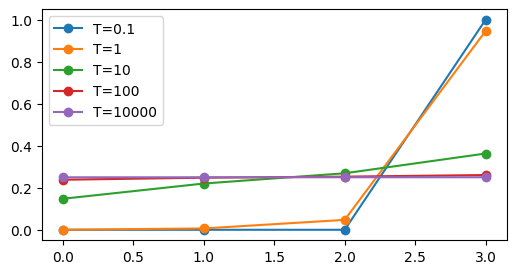

In [7]:
plt.figure(figsize=(6,3))
logits = np.asanyarray([1,5,7,10])
Ts = [0.1,1,10,100,10000]
for T in Ts:
  plt.plot(softmax_with_t(logits,T),'-o')
plt.legend(['T=0.1','T=1','T=10','T=100','T=10000'])

### model.generate

* `do_sample=True` :
* 温度越高，gibberish (乱语) ，raw token 依然会被采样到；
* 温度越低，coherent (连贯有条理)
    * less weird
    * temperature ->0, temperature scaled sampling becomes equal to greedy decoding
* coherence (low temperature) & diversity (high temperature) : trade off

In [8]:
prompt = 'In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.'
input_ids = tokenizer(prompt,return_tensors='pt').input_ids
input_ids

tensor([[  818,   257, 14702,  4917,    11, 11444,  5071,   257, 27638,   286,
         28000, 19942,  2877,   287,   257,  6569,    11,  4271, 31286,  1850,
         19272,    11,   287,   262,   843,   274, 21124,    13,  3412,   517,
          6452,   284,   262,  4837,   373,   262,  1109,   326,   262, 28000,
         19942,  5158,  2818,  3594,    13]])

In [9]:
output_t = model.generate(input_ids,max_length=128,do_sample=True,temperature=0.5,top_k=0)
tokenizer.decode(output_t[0])

"In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.\n\nThe discovery was made by a team of scientists from the University of Bristol in the UK, who were conducting a study on the genetics of the Andean unicorn. The researchers were looking for genetic clues to the species' history and the genetic basis of their unique traits.\n\nThe team of researchers led by Dr. Richard G. Wilson, a geneticist from the University of Bristol, was able to identify"

In [10]:
output_t = model.generate(input_ids,max_length=128,do_sample=True,temperature=1.,top_k=0)
tokenizer.decode(output_t[0])

'In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.\n\nThe "Uta" herd was discovered in Denemark, South America by Maria Abi-Camborn in 2012 and consisted of 47 individuals comprising of adult males, females and calves. Old females and young males were grouped together, as if attempting to avoid competition from young males. However, it turns out that this was not true as older donkeys and cattle were present as well.\n\nMost'

In [11]:
output_t = model.generate(input_ids,max_length=128,do_sample=True,temperature=2.,top_k=0)
tokenizer.decode(output_t[0])

'In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English. It gets crispest every higher that Capital disregma preempts the true pragmatic gains bus culri sec aster Herbjacoti COUNNECDC within feels overseen assumed cor mineral bounds proving so graphics notorAre h�� viewing spores issues NULL supervised sense causes audio mental occupied decoding Republicans Str thirsty betisd rage Philip Tinance Fres collateralitatively Up rather than punishing class style cosolo xen disciplined roommate curious ge to biod aff Giving Caronic'

### top_k & nucleus sampling (top_p)

* 平衡 coherent & diversity 的另外一种方式， truncate the distribution of the vocabulary.
    * 在 coherent 中寻求 diversity
* top-k 与 nucleus sampling (top-p): 限制采样的范围 (tokens) ;
    * top-k: 刚性的限制
        * 避免低概率地选择
        * top_k == 0 时，deactivate top_k, 不对候选 tokens 的数量进行限制
    * nucleus sampling (top-p) : 核采样
* 参考:
    * https://huggingface.co/blog/how-to-generate

In [12]:
output_topk = model.generate(input_ids,max_length=128,do_sample=True,top_k=50)
print(tokenizer.decode(output_topk[0]))

In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.

According to researchers Dr. Jonathan Day and Dr. James O. Hales, they studied the species, named Caledonian Unicorn. The discovery of the species had been made by a team of researchers, under the direction of Dr. Jonathan Day a Senior Research Fellow. Hales had made a few attempts at getting the unicorn's contact information. The response he got was from the local director of wildlife.


In [14]:
output_topp = model.generate(input_ids,max_length=128,do_sample=True,top_p=0.90)
print(tokenizer.decode(output_topp[0]))

In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.

Unicorns are known to have existed as long ago as 1.5 million years ago and were even worshipped by ancient Egyptian pharaohs. It was not until the 1800's that a group of scientist realized how closely related the unicorns in question were to the horses, which are related to horses as well.

The unicorns of the Andes Mountains, are closely related to the horses of
